# Определение ориентации OCR-кропов

## Target

Для каждого изображения оценить `p_180` - вероятность того, что текст повернут на 180°.

## Метрика

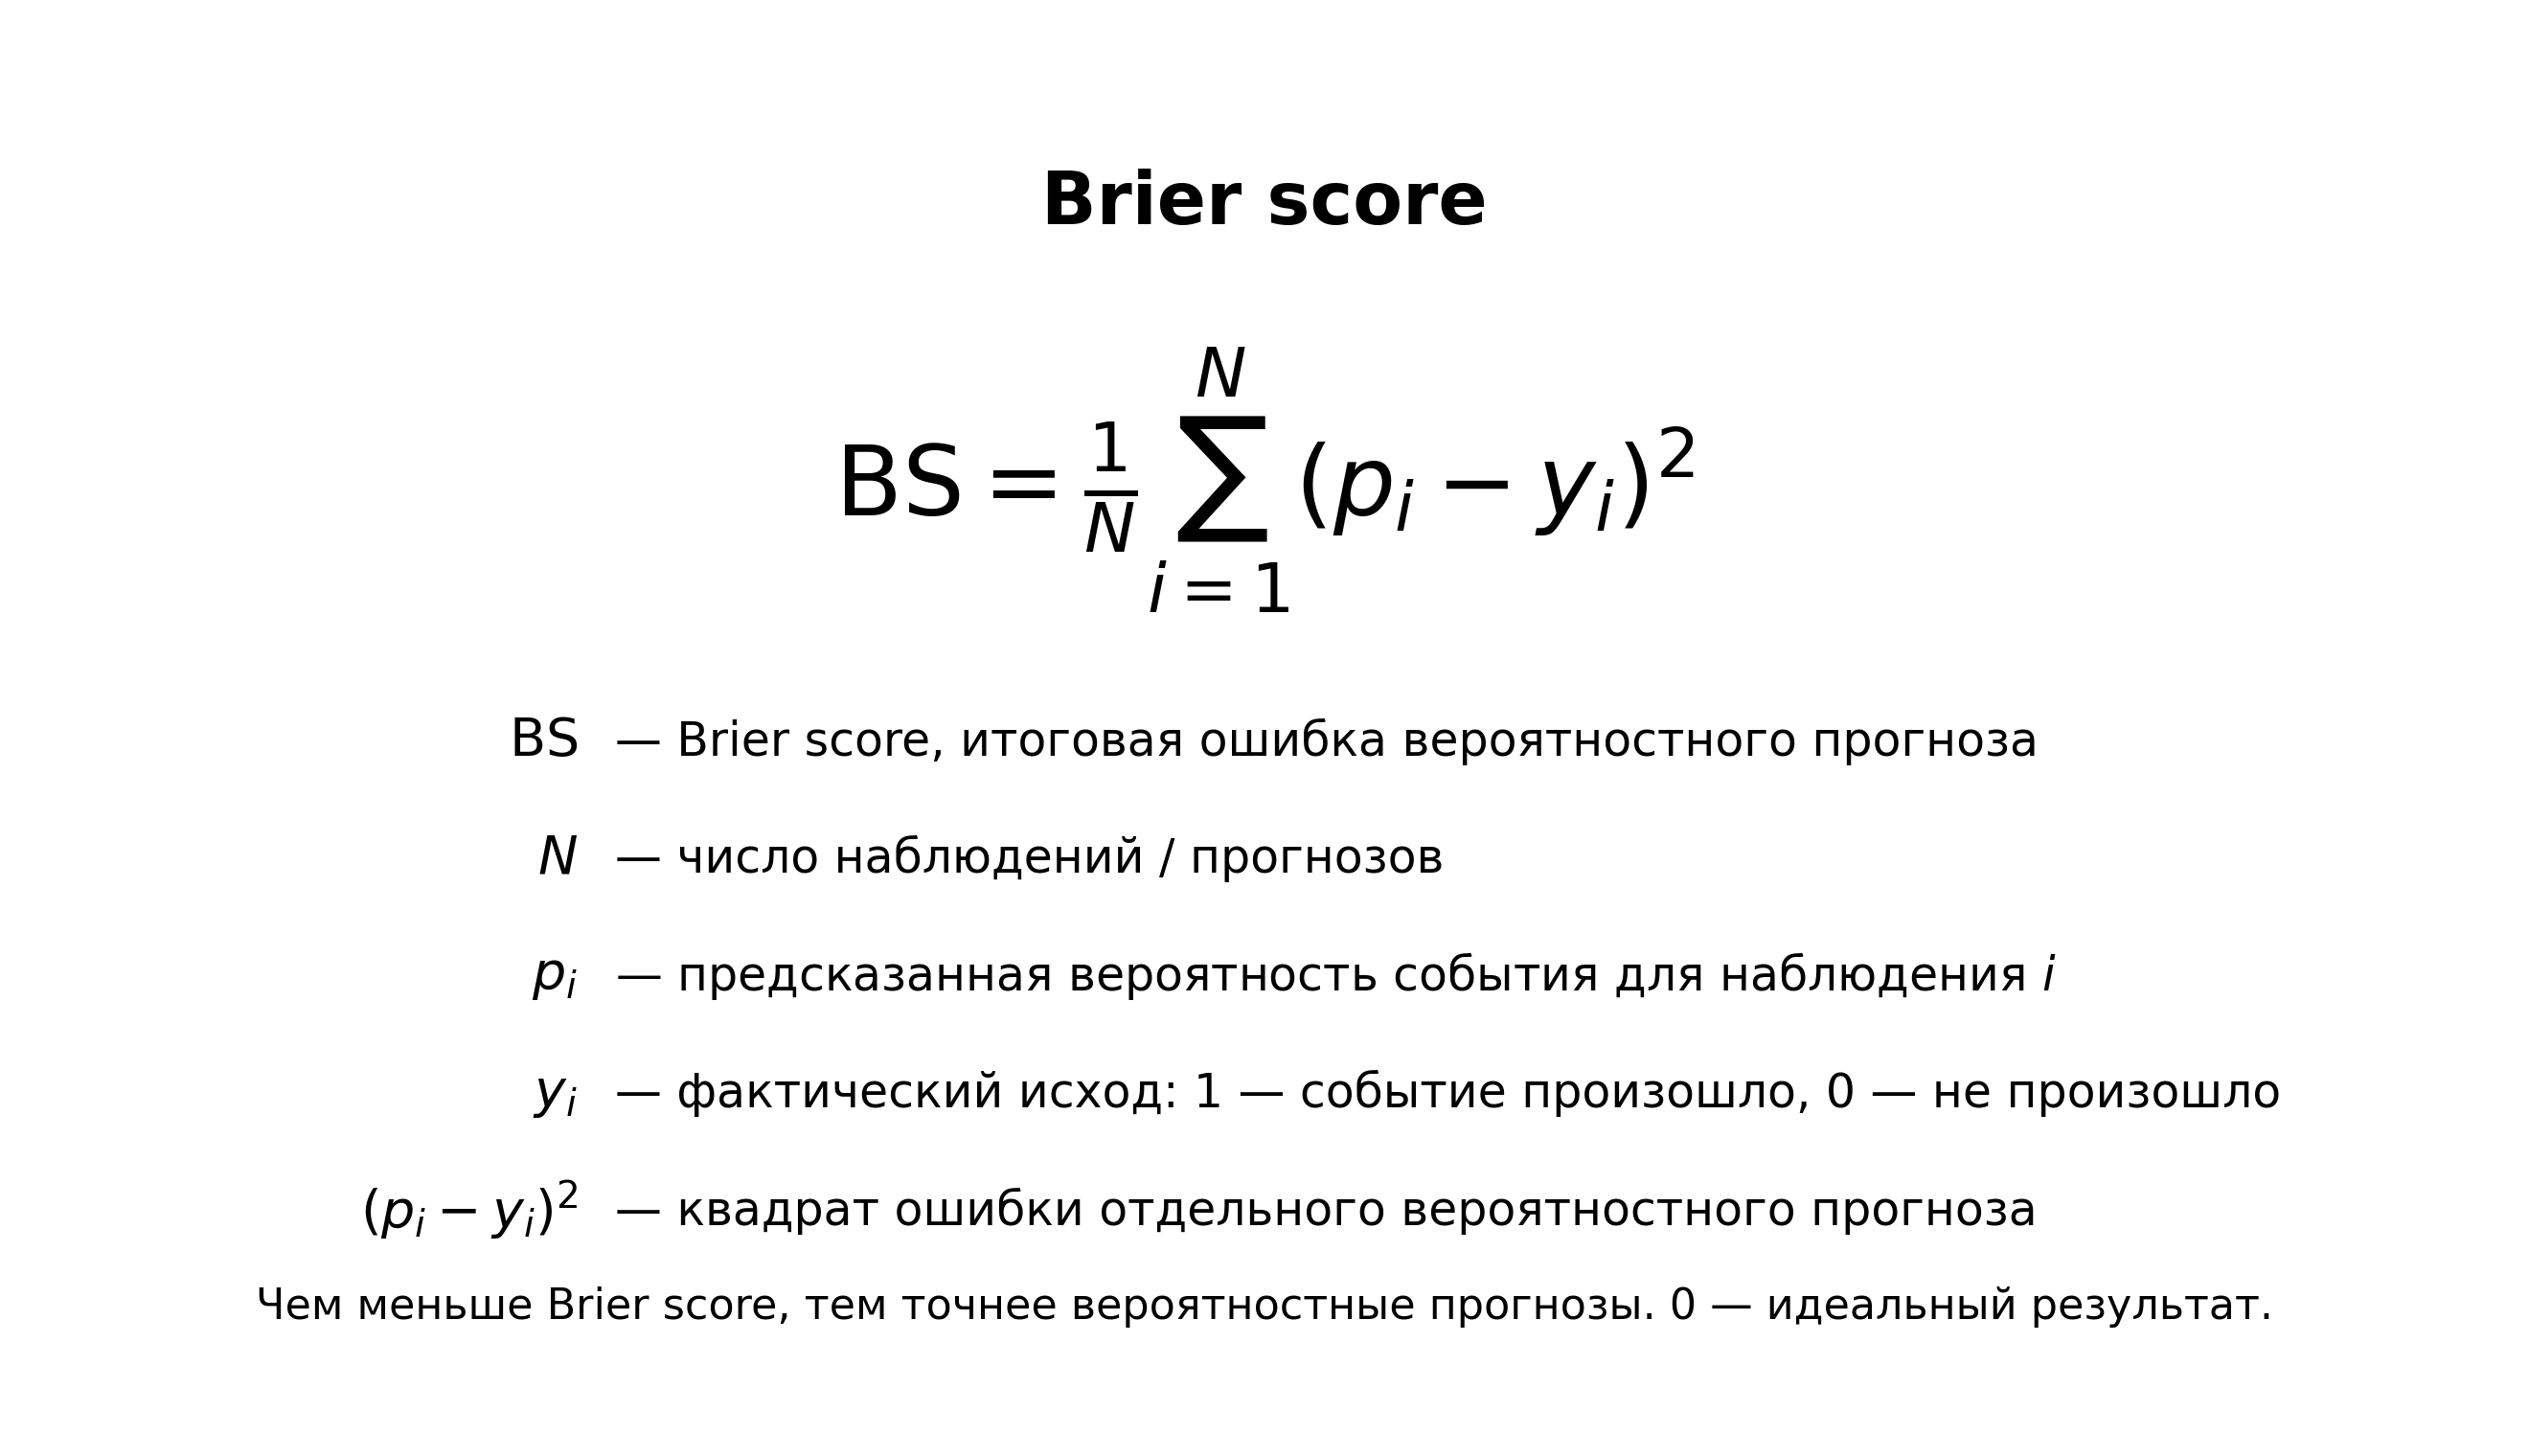

В ходе работы проверяются четыре идеи:

1. специализированный классификатор PaddleOCR;
2. MobileNetV3 на синтетических парах;
3. калибровка PaddleOCR и препроцессинг на внешних OCR-кропах;
4. семантический OCR likelihood как второй эксперт

`PP-LCNet_x1_0_textline_ori` - локальный модуль классификации ориентации текстовой строки: [Text Line Orientation Classification](https://www.paddleocr.ai/v3.1.0/en/version3.x/module_usage/textline_orientation_classification.html) (1.7 млн параметров).

[`eslav_PP-OCRv5_mobile_rec`](https://www.paddleocr.ai/v3.1.0/en/version3.x/module_usage/text_recognition.html) - распознаватель восточнославянского и английского текста (2 млн параметров).

---

Первая MobileNet хорошо решила синтетическую валидацию (`0.979`), но получила почти случайный результат на тесте (`0.75366686`) $\Rightarrow$ сильный сдвиг домена. Поэтому обучение MobileNet и ансамбль с ней не вошли в итоговый код.

По этой причине используются публичные датасеты: IIIT5K, SVT, SVTP и CUTE80 из [подборки для распознавания текста](https://github.com/longshangbang/Case-Sensitive-Scene-Text-Recognition-Datasets).

## Настройки окружения

In [ ]:
import hashlib
import importlib.util
from importlib.metadata import PackageNotFoundError, version as package_version
import json
import math
import os
import random
import subprocess
import sys
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch

In [ ]:
base_requirements = {
    "numpy": "numpy>=1.26,<3",
    "PIL": "pillow==11.1.0",
    "pandas": "pandas==2.2.3",
    "tqdm": "tqdm==4.67.1",
}
missing = [
    package
    for module, package in base_requirements.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch>=2.2"])

In [ ]:
print("Python:", sys.version.split()[0])
# print("PyTorch:", torch.__version__, "torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.13.15
PyTorch: 2.11.0+cu128 torchvision: 0.26.0+cu128
CUDA available: True


In [ ]:
TEST_ZIP = None

RUN_OCR_LIKELIHOOD = True

# содержимое submission.csv
# при auto_external выбирается с минимальным Brier
FINAL_SOURCE = "auto_external"

PADDLE_ORI_MODEL = "PP-LCNet_x1_0_textline_ori"
OCR_MODEL = "eslav_PP-OCRv5_mobile_rec"

PUBLIC_DATA_DIR = None
PUBLIC_DATA_URL = (
    "https://github.com/longshangbang/"
    "Case-Sensitive-Scene-Text-Recognition-Datasets/archive/refs/heads/master.zip"
)
PUBLIC_FIT_MAX = 2_500
PUBLIC_EVAL_MAX = 3_500

PADDLE_PREPROCESS_CANDIDATES = ("windows", "full")
CALIBRATION_L2 = 1e-4
META_L2 = 1e-4
META_MIN_IMPROVEMENT = 1e-3

INPUT_H, INPUT_W = 48, 192
MAX_WINDOWS = 3

if Path("/kaggle/working").exists():
    WORK_DIR = Path("/kaggle/working/ocr_orientation")
else:
    WORK_DIR = Path("/content/ocr_orientation")

OUTPUT_DIR = WORK_DIR / "outputs"
EXTRACT_DIR = WORK_DIR / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything()

{'device': 'cuda', 'quick_mode': False, 'train_pairs': 60000, 'val_pairs': 6000, 'epochs': 7, 'batch_size': 256, 'work_dir': '/content/ocr_orientation'}


## Загрузка данных

In [ ]:
# универсальная загрузка test.zip для тестирования на colab и kaggle была сделана с помощью LLM

def locate_test_zip(explicit=None) -> Path:
    candidates = []
    if explicit:
        candidates.append(Path(explicit))

    candidates += [Path("/content/test.zip"), Path("/kaggle/working/test.zip"), Path("test.zip")]
    for root in [Path("/kaggle/input"), Path("/content/drive/MyDrive")]:
        if root.exists():
            candidates.extend(root.glob("**/test.zip"))
    for path in candidates:
        if path.is_file():
            return path.resolve()
    raise FileNotFoundError("test.zip")

test_zip_path = locate_test_zip(TEST_ZIP)
print("test.zip:", test_zip_path)

marker = EXTRACT_DIR / ".extracted_ok"
if not marker.exists():
    with zipfile.ZipFile(test_zip_path) as zf:
        zf.extractall(EXTRACT_DIR)
    marker.write_text("ok", encoding="utf-8")

sample_candidates = list(EXTRACT_DIR.rglob("sample_submission.csv"))
if len(sample_candidates) != 1:
    raise RuntimeError()

sample_path = sample_candidates[0]
sample = pd.read_csv(sample_path)
assert list(sample.columns) == ["image_id", "p_180"]
assert sample["image_id"].is_unique

all_images = list(EXTRACT_DIR.rglob("*.png"))
image_by_id = {p.stem: p for p in all_images}
missing_ids = [x for x in sample.image_id.astype(str) if x not in image_by_id]
assert not missing_ids, f"Не найдены изображения, первые id: {missing_ids[:5]}"
test_paths = [image_by_id[x] for x in sample.image_id.astype(str)]

print("rows:", len(sample), "images:", len(test_paths))
display(sample.head())

test.zip: /content/test.zip
rows: 20000 images: 20000


,image_id,p_180
0,test_00000,0.5
1,test_00001,0.5
2,test_00002,0.5
3,test_00003,0.5
4,test_00004,0.5


In [ ]:
submissions = {}


def save_submission(name, probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    assert probabilities.shape == (len(sample),)
    assert np.isfinite(probabilities).all()
    assert ((0.0 <= probabilities) & (probabilities <= 1.0)).all()

    result = sample[["image_id"]].copy()
    result["p_180"] = probabilities
    path = OUTPUT_DIR / f"submission_{name}.csv"
    result.to_csv(path, index=False, float_format="%.8f")

    check = pd.read_csv(path)
    assert list(check.columns) == ["image_id", "p_180"]
    assert len(check) == len(sample)
    submissions[name] = probabilities
    print(path, "mean=", round(float(probabilities.mean()), 5))

    return path

## Предобработка изображений

Для режима `windows` строка масштабируется до фиксированной высоты с сохранением пропорций. Короткие строки дополняются до размера окна, а из длинных берутся несколько равномерно расположенных окон.

`full` передает PaddleOCR полный кроп без этой обработки.

In [ ]:
def read_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB")


def normalize_height(image, height=INPUT_H):
    scale = height / max(1, image.height)
    width = max(1, round(image.width * scale))
    return image.resize((width, height), Image.Resampling.BILINEAR)


def pad_window(image, width=INPUT_W, height=INPUT_H):
    if image.size == (width, height):
        return image

    array = np.asarray(image, dtype=np.uint8)
    border = np.concatenate([
        array[:, 0], array[:, -1], array[0], array[-1]
    ])
    fill = tuple(np.median(border, axis=0).astype(np.uint8).tolist())

    canvas = Image.new("RGB", (width, height), fill)
    canvas.paste(image, ((width - image.width) // 2, (height - image.height) // 2))
    return canvas


def image_windows(image, max_windows=MAX_WINDOWS):
    image = normalize_height(image)
    if image.width <= INPUT_W:
        return [pad_window(image)]

    count = min(max_windows, math.ceil(image.width / INPUT_W))
    starts = np.linspace(0, image.width - INPUT_W, count).round().astype(int)

    return [image.crop((int(x), 0, int(x) + INPUT_W, INPUT_H)) for x in starts]

## PaddleOCR

Для изображения `x` и его повернутой копии `R(x)` вычисляются логиты, после чего используется

$$
z_{sym}(x)= \frac{z(x) - z(Rx)}{2}.
$$

С симметризацией выполняется `p(Rx) = 1 - p(x)`

In [ ]:
PADDLE_VERSIONS = {
    "paddlepaddle": "3.0.0",
    "paddlex": "3.1.0",
    "paddleocr": "3.1.1",
}


def installed_version(distribution: str):
    try:
        return package_version(distribution)
    except PackageNotFoundError:
        return None


def prepare_paddle_environment():
    stack_changed = {name: installed_version(name) for name in PADDLE_VERSIONS} != PADDLE_VERSIONS
    modules_were_loaded = any(name in sys.modules for name in ("paddle", "paddlex", "paddleocr"))

    if stack_changed:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            *(f"{name}=={version}" for name, version in PADDLE_VERSIONS.items()),
        ])
        importlib.invalidate_caches()

    conflicting_optional = [
        name
        for name in ("langchain", "langchain-community")
        if installed_version(name) is not None
    ]
    if conflicting_optional:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "uninstall",
            "-y",
            "-q",
            *conflicting_optional,
        ])
        importlib.invalidate_caches()

    if modules_were_loaded and (stack_changed or conflicting_optional):
        raise RuntimeError(
            "paddle dependencies changed. restart the kernel and run all cells again."
        )

    print("Paddle stack:", {name: installed_version(name) for name in PADDLE_VERSIONS})


prepare_paddle_environment()
os.environ.setdefault("PADDLE_PDX_MODEL_SOURCE", "BOS")

from paddleocr import TextLineOrientationClassification

paddle_ori = TextLineOrientationClassification(
    model_name=PADDLE_ORI_MODEL,
    device="cpu",
    enable_mkldnn=True,
    cpu_threads=max(1, min(8, os.cpu_count() or 1)),
)
print("Loaded:", PADDLE_ORI_MODEL)

Paddle stack: {'paddlepaddle': '3.0.0', 'paddlex': '3.1.0', 'paddleocr': '3.1.1'}


/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/official_inference_model/paddle3.0.0/PP-LCNet_x1_0_textline_ori_infer.tar ...
[==================================================] 100.00%
Extracting PP-LCNet_x1_0_textline_ori_infer.tar
[==================================================] 100.00%


Loaded: PP-LCNet_x1_0_textline_ori


In [ ]:
def result_payload(result):
    payload = result.json
    if callable(payload):
        payload = payload()
    if isinstance(payload, str):
        payload = json.loads(payload)

    return payload.get("res", payload)


def paddle_result_to_logit(result, eps: float = 1e-5) -> float:
    payload = result_payload(result)
    label = str(np.asarray(payload["label_names"]).reshape(-1)[0])

    confidence = float(np.asarray(payload["scores"]).reshape(-1)[0])
    p180 = confidence if "180" in label else 1.0 - confidence
    p180 = float(np.clip(p180, eps, 1.0 - eps))

    return math.log(p180 / (1.0 - p180))


def paddle_views(image: Image.Image, preprocess: str):
    if preprocess == "full":
        return [image]
    if preprocess == "windows":
        return image_windows(image)

    raise ValueError(f"Unknown Paddle preprocessing: {preprocess}")


# усредняет логиты по окнам и симметризует прогноз
def paddle_orientation_predict(paths, batch_size: int = 64, symmetric: bool = True, preprocess: str = "windows"):
    owner, side, arrays = [], [], []
    sum_logits = np.zeros((len(paths), 2 if symmetric else 1), dtype=np.float64)
    counts = np.zeros_like(sum_logits)

    def flush():
        nonlocal arrays, owner, side
        if not arrays:
            return

        results = paddle_ori.predict(arrays, batch_size=min(batch_size, len(arrays)))
        for result, image_index, orientation_index in zip(results, owner, side):
            sum_logits[image_index, orientation_index] += paddle_result_to_logit(result)
            counts[image_index, orientation_index] += 1

        arrays, owner, side = [], [], []


    for image_index, path in enumerate(tqdm(paths, desc=f"Paddle ({preprocess})")):
        image = read_rgb(path)

        for view in paddle_views(image, preprocess):
            arrays.append(np.asarray(view, dtype=np.uint8)[:, :, ::-1].copy())
            owner.append(image_index)
            side.append(0)

        if symmetric:
            rotated = image.transpose(Image.Transpose.ROTATE_180)

            for view in paddle_views(rotated, preprocess):
                arrays.append(np.asarray(view, dtype=np.uint8)[:, :, ::-1].copy())
                owner.append(image_index)
                side.append(1)

        if len(arrays) >= batch_size * 4:
            flush()

    flush()

    mean_logits = sum_logits / np.maximum(counts, 1)

    if symmetric:
        logits = 0.5 * (mean_logits[:, 0] - mean_logits[:, 1])
    else:
        logits = mean_logits[:, 0]

    probabilities = 1.0 / (1.0 + np.exp(-np.clip(logits, -30, 30)))
    return probabilities.astype(np.float64), logits.astype(np.float64)

In [ ]:
paddle_logits = None
paddle_test_logits_by_mode = {}

paddle_prob, paddle_logits = paddle_orientation_predict(
    test_paths,
    symmetric=True,
    preprocess="windows",
)

paddle_test_logits_by_mode["windows"] = paddle_logits

save_submission("paddle_sym", paddle_prob)

Paddle (windows):   0%|          | 0/20000 [00:00<?, ?it/s]

/content/ocr_orientation/outputs/submission_paddle_sym.csv mean= 0.50451


## Внешняя валидация

Для калибровки используются: IIIT5K, SVT, SVTP и CUTE80 ([репозиторий](https://github.com/longshangbang/Case-Sensitive-Scene-Text-Recognition-Datasets), содержит 6837 кропов).

Для каждого исходного кропа создается точная копия с поворотом на 180 градусов.

Ближайший русскоязычный набор - [RusTitW](https://arxiv.org/abs/2303.16531), но он значительно более тяжелый и состоит из сцен, из которых пришлось бы отдельно извлекать боксы.

In [ ]:
EXTERNAL_ROOT = WORK_DIR / "external_validation"
EXTERNAL_ROOT.mkdir(parents=True, exist_ok=True)


def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        while chunk := stream.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


def prepare_public_validation() -> Path:
    if PUBLIC_DATA_DIR is not None:
        root = Path(PUBLIC_DATA_DIR).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(root)

        return root

    archive = EXTERNAL_ROOT / "case_sensitive_str_datasets.zip"
    extracted = EXTERNAL_ROOT / "case_sensitive_str_datasets"
    marker = extracted / ".complete"

    if not archive.exists():
        print("Downloading public OCR validation...")

        try:
            urllib.request.urlretrieve(PUBLIC_DATA_URL, archive)
        except Exception as exc:
            raise RuntimeError(exc)

    if not marker.exists():
        extracted.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(extracted)

        marker.write_text("ok", encoding="utf-8")

    manifest = {
        "url": PUBLIC_DATA_URL,
        "sha256": sha256_file(archive),
        "archive_bytes": archive.stat().st_size,
    }
    (EXTERNAL_ROOT / "manifest.json").write_text(
        json.dumps(manifest, indent=2), encoding="utf-8"
    )
    print("Public archive SHA-256:", manifest["sha256"])

    return extracted


def find_named_directory(root: Path, name: str) -> Path:
    matches = [path for path in root.rglob(name) if path.is_dir()]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one {name!r} directory, found: {matches}")

    return matches[0]


def image_files(directory: Path):
    suffixes = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}
    return sorted(path for path in directory.rglob("*") if path.suffix.lower() in suffixes)


def deterministic_limit(paths, limit: int, seed: int):
    paths = list(paths)
    if len(paths) <= limit:
        return paths

    rng = np.random.default_rng(seed)
    indices = np.sort(rng.choice(len(paths), size=limit, replace=False))
    return [paths[int(index)] for index in indices]

In [ ]:
public_root = prepare_public_validation()
fit_sources = ("iiit5k_train", "svt_train")
eval_sources = ("iiit5k_test", "svt_test", "svtp_test", "cute80_test")

public_fit_paths = []
public_eval_paths = []
public_counts = {}

for source in fit_sources:
    paths = image_files(find_named_directory(public_root, source))
    public_counts[source] = len(paths)
    public_fit_paths.extend(paths)

for source in eval_sources:
    paths = image_files(find_named_directory(public_root, source))
    public_counts[source] = len(paths)
    public_eval_paths.extend(paths)


public_fit_paths = deterministic_limit(public_fit_paths, PUBLIC_FIT_MAX, SEED + 301)
public_eval_paths = deterministic_limit(public_eval_paths, PUBLIC_EVAL_MAX, SEED + 302)

assert public_fit_paths and public_eval_paths
assert not set(public_fit_paths) & set(public_eval_paths)
print("Public source counts:", public_counts)
print("Used for fit:", len(public_fit_paths), "used for evaluation:", len(public_eval_paths))

Public archive SHA-256: 22bc4f6e9be994702d6f36f5956131db2f1aa4e31b4ecb3338ce8e710945b45d
Public source counts: {'iiit5k_train': 2000, 'svt_train': 257, 'iiit5k_test': 3000, 'svt_test': 647, 'svtp_test': 645, 'cute80_test': 288}
Used for fit: 2257 used for evaluation: 3500


## Препроцессинг и калибровка PaddleOCR

Проверяются полный кроп (`full`) и несколько окон (`windows`). Для каждого режима на обучающей части подбирается один коэффициент температуры минимизацией Brier Score с небольшой L2-регуляризацией.

Оба варианта сравниваются на контрольной части, после чего температура переоценивается на публичных кропах. Это добавляет один скаляр и не меняет размер или скорость модели.

In [ ]:
def symmetric_pair_arrays(upright_logits):
    upright_logits = np.asarray(upright_logits, dtype=np.float64)
    logits = np.concatenate([upright_logits, -upright_logits])

    targets = np.concatenate([
        np.zeros(len(upright_logits), dtype=np.float64),
        np.ones(len(upright_logits), dtype=np.float64),
    ])

    return logits, targets


def sigmoid_np(logits):
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -30, 30)))


def probability_metrics(probabilities, targets):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    targets = np.asarray(targets, dtype=np.float64)

    brier = float(np.mean((probabilities - targets) ** 2))
    accuracy = float(np.mean((probabilities >= 0.5) == (targets >= 0.5)))
    return {"brier": brier, "score": 1.0 - brier, "accuracy": accuracy}


def fit_temperature_grid(logits, targets, l2: float = CALIBRATION_L2):
    logits = np.asarray(logits, dtype=np.float64)
    targets = np.asarray(targets, dtype=np.float64)

    scales = np.exp(np.linspace(np.log(0.10), np.log(4.0), 801))
    objectives = []
    for scale in scales:
        brier = np.mean((sigmoid_np(scale * logits) - targets) ** 2)
        objectives.append(brier + l2 * np.log(scale) ** 2)

    best = int(np.argmin(objectives))
    return float(1.0 / scales[best])

In [ ]:
public_paddle_logits = {}
preprocess_rows = []

for mode in PADDLE_PREPROCESS_CANDIDATES:
    _, fit_upright_logits = paddle_orientation_predict(public_fit_paths, preprocess=mode, symmetric=True)
    _, eval_upright_logits = paddle_orientation_predict(public_eval_paths, preprocess=mode, symmetric=True)
    public_paddle_logits[mode] = {
        "fit": fit_upright_logits,
        "eval": eval_upright_logits,
    }

    fit_logits, fit_targets = symmetric_pair_arrays(fit_upright_logits)
    eval_logits, eval_targets = symmetric_pair_arrays(eval_upright_logits)
    temperature = fit_temperature_grid(fit_logits, fit_targets)

    raw_metrics = probability_metrics(sigmoid_np(eval_logits), eval_targets)
    calibrated_metrics = probability_metrics(
        sigmoid_np(eval_logits / temperature), eval_targets
    )
    preprocess_rows.append({
        "preprocess": mode,
        "temperature_fit": temperature,
        "eval_raw_brier": raw_metrics["brier"],
        "eval_calibrated_brier": calibrated_metrics["brier"],
        "eval_calibrated_score": calibrated_metrics["score"],
        "eval_accuracy": calibrated_metrics["accuracy"],
    })


preprocess_results = pd.DataFrame(preprocess_rows).sort_values("eval_calibrated_brier").reset_index(drop=True)
preprocess_results.to_csv(OUTPUT_DIR / "external_preprocessing_results.csv", index=False)
display(preprocess_results)


best_paddle_preprocess = str(preprocess_results.loc[0, "preprocess"])
selected_fit_temperature = float(preprocess_results.loc[0, "temperature_fit"])
selected_public_logits = np.concatenate([
    public_paddle_logits[best_paddle_preprocess]["fit"],
    public_paddle_logits[best_paddle_preprocess]["eval"],
])
all_pair_logits, all_pair_targets = symmetric_pair_arrays(selected_public_logits)
final_paddle_temperature = fit_temperature_grid(all_pair_logits, all_pair_targets)


if best_paddle_preprocess not in paddle_test_logits_by_mode:
    _, selected_test_paddle_logits = paddle_orientation_predict(
        test_paths,
        preprocess=best_paddle_preprocess,
        symmetric=True,
    )
    paddle_test_logits_by_mode[best_paddle_preprocess] = selected_test_paddle_logits
else:
    selected_test_paddle_logits = paddle_test_logits_by_mode[best_paddle_preprocess]

paddle_calibrated_prob = sigmoid_np(selected_test_paddle_logits / final_paddle_temperature)
save_submission("paddle_calibrated", paddle_calibrated_prob)

external_best_source = "paddle_calibrated"
best_external_eval_brier = float(preprocess_results.loc[0, "eval_calibrated_brier"])

print("Selected preprocessing:", best_paddle_preprocess)
print("Final temperature:", final_paddle_temperature)
print("External selection currently:", external_best_source)

Paddle (windows):   0%|          | 0/2257 [00:00<?, ?it/s]

Paddle (windows):   0%|          | 0/3500 [00:00<?, ?it/s]

Paddle (full):   0%|          | 0/2257 [00:00<?, ?it/s]

Paddle (full):   0%|          | 0/3500 [00:00<?, ?it/s]

,preprocess,temperature_fit,eval_raw_brier,eval_calibrated_brier,eval_calibrated_score,eval_accuracy
0,full,0.702291,0.029022,0.029222,0.970778,0.960000
1,windows,0.821494,0.040070,0.040718,0.959282,0.944286


Paddle (full):   0%|          | 0/20000 [00:00<?, ?it/s]

/content/ocr_orientation/outputs/submission_paddle_calibrated.csv mean= 0.50321
Selected preprocessing: full
Final temperature: 0.825290661397916
External selection currently: paddle_calibrated


## OCR likelihood

Правильно ориентированный текст обычно распознается увереннее. Поэтому для исходного и повернутого изображения вычисляется

$$
s_{ocr}= \operatorname{logit} q(Rx) - \operatorname{logit} q(x),
$$

где `q` - уверенность. Вместе с логитом этот признак подается в модель с двумя коэффициентами:

$$
p_{180} = \sigma(a \, s_{paddle} + b \, s_{ocr}).
$$

Коэффициенты минимизируют Brier Score с L2-регуляризацией.

In [ ]:
def confidence_to_logit(score, eps: float = 1e-4):
    score = float(np.clip(score, eps, 1.0 - eps))
    return math.log(score / (1.0 - score))


def recognition_delta(recognizer, paths, batch_size: int = 64):
    score_original = np.zeros(len(paths), dtype=np.float64)
    score_rotated = np.zeros(len(paths), dtype=np.float64)
    arrays, owners, sides = [], [], []

    def flush():
        nonlocal arrays, owners, sides
        if not arrays:
            return

        output = recognizer.predict(arrays, batch_size=min(batch_size, len(arrays)))
        for result, owner, side in zip(output, owners, sides):
            payload = result_payload(result)
            score = float(np.asarray(payload["rec_score"]).reshape(-1)[0])
            if side == 0:
                score_original[owner] = score
            else:
                score_rotated[owner] = score

        arrays, owners, sides = [], [], []


    for index, path in enumerate(tqdm(paths, desc="OCR likelihood")):
        image = read_rgb(path)
        rotated = image.transpose(Image.Transpose.ROTATE_180)
        arrays.extend([
            np.asarray(image, dtype=np.uint8)[:, :, ::-1].copy(),
            np.asarray(rotated, dtype=np.uint8)[:, :, ::-1].copy(),
        ])

        owners.extend([index, index])
        sides.extend([0, 1])

        if len(arrays) >= batch_size * 2:
            flush()

    flush()

    original_logits = np.asarray([confidence_to_logit(x) for x in score_original])
    rotated_logits = np.asarray([confidence_to_logit(x) for x in score_rotated])
    return rotated_logits - original_logits


def symmetric_feature_pairs(paddle_logits, ocr_logits):
    upright = np.column_stack([paddle_logits, ocr_logits]).astype(np.float32)
    features = np.concatenate([upright, -upright], axis=0)

    targets = np.concatenate([
        np.zeros(len(upright), dtype=np.float32),
        np.ones(len(upright), dtype=np.float32),
    ])

    return features, targets


def fit_brier_linear(features, targets, initial, l2: float = META_L2):
    x = torch.tensor(np.asarray(features), dtype=torch.float32)
    y = torch.tensor(np.asarray(targets), dtype=torch.float32)
    weights = torch.tensor(initial, dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [weights], lr=0.2, max_iter=150, line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()
        probabilities = torch.sigmoid(x @ weights)
        brier = (probabilities - y).square().mean()
        penalty = l2 * weights.square().sum()
        loss = brier + penalty
        loss.backward()

        return loss

    optimizer.step(closure)
    return weights.detach().cpu().numpy().astype(np.float64)

In [ ]:
ocr_delta = None
ocr_meta_weights = None
ocr_meta_eval_metrics = None

if RUN_OCR_LIKELIHOOD:
    prepare_paddle_environment()
    os.environ.setdefault("PADDLE_PDX_MODEL_SOURCE", "BOS")

    from paddleocr import TextRecognition

    recognizer = TextRecognition(model_name=OCR_MODEL, device="cpu")

    fit_ocr_delta = recognition_delta(recognizer, public_fit_paths)
    eval_ocr_delta = recognition_delta(recognizer, public_eval_paths)

    fit_features, fit_targets = symmetric_feature_pairs(
        public_paddle_logits[best_paddle_preprocess]["fit"], fit_ocr_delta
    )
    eval_features, eval_targets = symmetric_feature_pairs(
        public_paddle_logits[best_paddle_preprocess]["eval"], eval_ocr_delta
    )

    initial = [1.0 / selected_fit_temperature, 0.0]
    fit_weights = fit_brier_linear(fit_features, fit_targets, initial)
    eval_probabilities = sigmoid_np(eval_features @ fit_weights)
    ocr_meta_eval_metrics = probability_metrics(eval_probabilities, eval_targets)

    all_features = np.concatenate([fit_features, eval_features], axis=0)
    all_targets = np.concatenate([fit_targets, eval_targets], axis=0)
    ocr_meta_weights = fit_brier_linear(all_features, all_targets, fit_weights)

    test_ocr_delta = recognition_delta(recognizer, test_paths)
    test_meta_features = np.column_stack([selected_test_paddle_logits, test_ocr_delta])

    paddle_ocr_meta_prob = sigmoid_np(test_meta_features @ ocr_meta_weights)
    save_submission("paddle_ocr_meta", paddle_ocr_meta_prob)

    improvement = best_external_eval_brier - ocr_meta_eval_metrics["brier"]
    if improvement >= META_MIN_IMPROVEMENT:
        external_best_source = "paddle_ocr_meta"
        best_external_eval_brier = ocr_meta_eval_metrics["brier"]

    print("Meta weights [Paddle, OCR]:", ocr_meta_weights)
    print("Held-out external metrics:", ocr_meta_eval_metrics)
    print("Held-out Brier improvement vs Paddle:", improvement)
    print("External selection:", external_best_source)

Using official model (eslav_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Paddle stack: {'paddlepaddle': '3.0.0', 'paddlex': '3.1.0', 'paddleocr': '3.1.1'}


Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/official_inference_model/paddle3.0.0/eslav_PP-OCRv5_mobile_rec_infer.tar ...
[==================================================] 100.00%
Extracting eslav_PP-OCRv5_mobile_rec_infer.tar
[==================================================] 100.00%


OCR likelihood:   0%|          | 0/2257 [00:00<?, ?it/s]

OCR likelihood:   0%|          | 0/3500 [00:00<?, ?it/s]

OCR likelihood:   0%|          | 0/20000 [00:00<?, ?it/s]

/content/ocr_orientation/outputs/submission_paddle_ocr_meta.csv mean= 0.50181
Meta weights [Paddle, OCR]: [0.63496286 0.81330132]
Held-out external metrics: {'brier': 0.017415699581025547, 'score': 0.9825843004189745, 'accuracy': 0.9751428571428571}
Held-out Brier improvement vs Paddle: 0.011806656665651977
External selection: paddle_ocr_meta


## Итоговый submission


In [ ]:
selected_source = external_best_source if FINAL_SOURCE == "auto_external" else FINAL_SOURCE

final = sample[["image_id"]].copy()
final["p_180"] = submissions[selected_source]
final_path = OUTPUT_DIR / "submission.csv"
final.to_csv(final_path, index=False, float_format="%.8f")

reloaded = pd.read_csv(final_path)
assert reloaded.shape == (len(sample), 2)
assert list(reloaded.columns) == ["image_id", "p_180"]
assert reloaded.image_id.tolist() == sample.image_id.tolist()
assert reloaded.p_180.between(0, 1).all()
assert np.isfinite(reloaded.p_180).all()
assert np.allclose(reloaded.p_180.to_numpy(), submissions[selected_source], atol=5e-9)

calibration_payload = {
    "selected_source": selected_source,
    "best_paddle_preprocess": best_paddle_preprocess,
    "selected_fit_temperature": selected_fit_temperature,
    "paddle_temperature": final_paddle_temperature,
    "meta_min_improvement": META_MIN_IMPROVEMENT,
    "ocr_meta_weights": None if ocr_meta_weights is None else ocr_meta_weights.tolist(),
    "ocr_meta_eval_metrics": ocr_meta_eval_metrics,
}
(OUTPUT_DIR / "calibration.json").write_text(
    json.dumps(calibration_payload, indent=2), encoding="utf-8"
)

metadata = {
    "final_source": selected_source,
    "seed": SEED,
    "test_rows": len(sample),
    "paddle_model": PADDLE_ORI_MODEL,
    "public_data_url": PUBLIC_DATA_URL,
    "versions": {
        "python": sys.version.split()[0],
        "torch": torch.__version__,
        "pandas": pd.__version__,
    },
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("selected source:", selected_source)
print(final_path)

display(reloaded.head())

selected source: paddle_ocr_meta
/content/ocr_orientation/outputs/submission.csv


,image_id,p_180
0,test_00000,0.005204
1,test_00001,0.999893
2,test_00002,0.997608
3,test_00003,0.003536
4,test_00004,0.999728


In [ ]:
from google.colab import files

files.download(final_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Использованные open-source компоненты и данные

- PaddleOCR/PaddleX: `PP-LCNet_x1_0_textline_ori` и `eslav_PP-OCRv5_mobile_rec`;
- PyTorch: MobileNetV3-Small и ImageNet weights;
- IIIT5K, SVT, SVTP, CUTE80;
- Pillow, NumPy, pandas, matplotlib, tqdm.